In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv("../data/sujithmandala-diabetes.csv")
dataset

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40,High,160,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20,Normal,80,5.0,No,No,Healthy,Regular,No
...,...,...,...,...,...,...,...,...,...,...,...
123,17,Female,15,Normal,100,5.7,No,Yes,Poor,No,Yes
124,22,Male,19,Normal,120,6.4,No,Yes,Poor,No,Yes
125,27,Female,24,High,140,7.1,No,Yes,Poor,No,Yes
126,32,Male,29,High,160,7.8,No,Yes,Poor,No,Yes


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         128 non-null    int64  
 1   Gender                      128 non-null    object 
 2   BMI                         128 non-null    int64  
 3   Blood Pressure              128 non-null    object 
 4   FBS                         128 non-null    int64  
 5   HbA1c                       128 non-null    float64
 6   Family History of Diabetes  128 non-null    object 
 7   Smoking                     128 non-null    object 
 8   Diet                        128 non-null    object 
 9   Exercise                    128 non-null    object 
 10  Diagnosis                   128 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 11.1+ KB


In [4]:
dataset.Diagnosis.value_counts()

No     97
Yes    31
Name: Diagnosis, dtype: int64

In [5]:
dataset.Gender.replace(["Male", "Female"], [0, 1], inplace=True)

In [6]:
dataset["Family History of Diabetes"].replace(["No", "Yes"], [0, 1], inplace=True)
dataset["Smoking"].replace(["No", "Yes"], [0, 1], inplace=True)
dataset["Diagnosis"].replace(["No", "Yes"], [0, 1], inplace=True)

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         128 non-null    int64  
 1   Gender                      128 non-null    int64  
 2   BMI                         128 non-null    int64  
 3   Blood Pressure              128 non-null    object 
 4   FBS                         128 non-null    int64  
 5   HbA1c                       128 non-null    float64
 6   Family History of Diabetes  128 non-null    int64  
 7   Smoking                     128 non-null    int64  
 8   Diet                        128 non-null    object 
 9   Exercise                    128 non-null    object 
 10  Diagnosis                   128 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 11.1+ KB


In [8]:
dataset.Diet.value_counts()

Poor       79
Healthy    49
Name: Diet, dtype: int64

In [10]:
dataset["Diet"].replace(["Poor", "Healthy"], [0, 1], inplace=True)

In [11]:
dataset.Exercise.value_counts()

No         79
Regular    49
Name: Exercise, dtype: int64

In [12]:
dataset["Exercise"].replace(["No", "Regular"], [0, 1], inplace=True)

In [13]:
dataset["Blood Pressure"].value_counts()

High      79
Normal    39
Low       10
Name: Blood Pressure, dtype: int64

In [15]:
dataset["Blood Pressure"].replace(["Low", "Normal", "High"], [0, 1, 2], inplace=True)

In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         128 non-null    int64  
 1   Gender                      128 non-null    int64  
 2   BMI                         128 non-null    int64  
 3   Blood Pressure              128 non-null    int64  
 4   FBS                         128 non-null    int64  
 5   HbA1c                       128 non-null    float64
 6   Family History of Diabetes  128 non-null    int64  
 7   Smoking                     128 non-null    int64  
 8   Diet                        128 non-null    int64  
 9   Exercise                    128 non-null    int64  
 10  Diagnosis                   128 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 11.1 KB


In [17]:
y = dataset["Diagnosis"]
x = dataset.drop("Diagnosis", axis=1)

x

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise
0,45,0,25,1,100,5.7,0,0,1,1
1,55,1,30,2,120,6.4,1,1,0,0
2,65,0,35,2,140,7.1,1,1,0,0
3,75,1,40,2,160,7.8,1,1,0,0
4,40,0,20,1,80,5.0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...
123,17,1,15,1,100,5.7,0,1,0,0
124,22,0,19,1,120,6.4,0,1,0,0
125,27,1,24,2,140,7.1,0,1,0,0
126,32,0,29,2,160,7.8,0,1,0,0


In [18]:
y

0      0
1      1
2      1
3      1
4      0
      ..
123    1
124    1
125    1
126    1
127    1
Name: Diagnosis, Length: 128, dtype: int64

## Scaler

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_scaled = pd.DataFrame(x_scaled, columns=x.columns)
x_scaled

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise
0,0.177576,-0.939336,-0.694184,-0.847344,-1.023182,-1.023182,-0.813841,-1.269742,1.269742,1.269742
1,0.775725,1.064581,-0.359133,0.724540,-0.695764,-0.695764,1.228741,0.787562,-0.787562,-0.787562
2,1.373875,-0.939336,-0.024082,0.724540,-0.368345,-0.368345,1.228741,0.787562,-0.787562,-0.787562
3,1.972025,1.064581,0.310969,0.724540,-0.040927,-0.040927,1.228741,0.787562,-0.787562,-0.787562
4,-0.121499,-0.939336,-1.029235,-0.847344,-1.350600,-1.350600,-0.813841,-1.269742,1.269742,1.269742
...,...,...,...,...,...,...,...,...,...,...
123,-1.497243,1.064581,-1.364286,-0.847344,-1.023182,-1.023182,-0.813841,0.787562,-0.787562,-0.787562
124,-1.198169,-0.939336,-1.096245,-0.847344,-0.695764,-0.695764,-0.813841,0.787562,-0.787562,-0.787562
125,-0.899094,1.064581,-0.761194,0.724540,-0.368345,-0.368345,-0.813841,0.787562,-0.787562,-0.787562
126,-0.600019,-0.939336,-0.426143,0.724540,-0.040927,-0.040927,-0.813841,0.787562,-0.787562,-0.787562


In [21]:
scaled_dataset = x_scaled.copy()
scaled_dataset["Diagnosis"] = y

scaled_dataset

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,0.177576,-0.939336,-0.694184,-0.847344,-1.023182,-1.023182,-0.813841,-1.269742,1.269742,1.269742,0
1,0.775725,1.064581,-0.359133,0.724540,-0.695764,-0.695764,1.228741,0.787562,-0.787562,-0.787562,1
2,1.373875,-0.939336,-0.024082,0.724540,-0.368345,-0.368345,1.228741,0.787562,-0.787562,-0.787562,1
3,1.972025,1.064581,0.310969,0.724540,-0.040927,-0.040927,1.228741,0.787562,-0.787562,-0.787562,1
4,-0.121499,-0.939336,-1.029235,-0.847344,-1.350600,-1.350600,-0.813841,-1.269742,1.269742,1.269742,0
...,...,...,...,...,...,...,...,...,...,...,...
123,-1.497243,1.064581,-1.364286,-0.847344,-1.023182,-1.023182,-0.813841,0.787562,-0.787562,-0.787562,1
124,-1.198169,-0.939336,-1.096245,-0.847344,-0.695764,-0.695764,-0.813841,0.787562,-0.787562,-0.787562,1
125,-0.899094,1.064581,-0.761194,0.724540,-0.368345,-0.368345,-0.813841,0.787562,-0.787562,-0.787562,1
126,-0.600019,-0.939336,-0.426143,0.724540,-0.040927,-0.040927,-0.813841,0.787562,-0.787562,-0.787562,1


### Correlação

In [23]:
correlation = scaled_dataset.corr(method='spearman')
correlation["Diagnosis"].sort_values(ascending=False)

Diagnosis                     1.000000
Smoking                       0.445225
Gender                        0.053674
Blood Pressure               -0.176593
Age                          -0.190396
BMI                          -0.286703
FBS                          -0.293725
HbA1c                        -0.293725
Family History of Diabetes   -0.348335
Diet                         -0.445225
Exercise                     -0.445225
Name: Diagnosis, dtype: float64

In [24]:
correlation = scaled_dataset.corr(method='kendall')
correlation["Diagnosis"].sort_values(ascending=False)

Diagnosis                     1.000000
Smoking                       0.445225
Gender                        0.053674
Age                          -0.158148
Blood Pressure               -0.171532
BMI                          -0.238191
FBS                          -0.251354
HbA1c                        -0.251354
Family History of Diabetes   -0.348335
Diet                         -0.445225
Exercise                     -0.445225
Name: Diagnosis, dtype: float64

In [25]:
correlation = scaled_dataset.corr(method='pearson')
correlation["Diagnosis"].sort_values(ascending=False)

Diagnosis                     1.000000
Smoking                       0.445225
Gender                        0.053674
Age                          -0.183219
Blood Pressure               -0.192370
BMI                          -0.304452
FBS                          -0.315709
HbA1c                        -0.315709
Family History of Diabetes   -0.348335
Diet                         -0.445225
Exercise                     -0.445225
Name: Diagnosis, dtype: float64

### Relevância

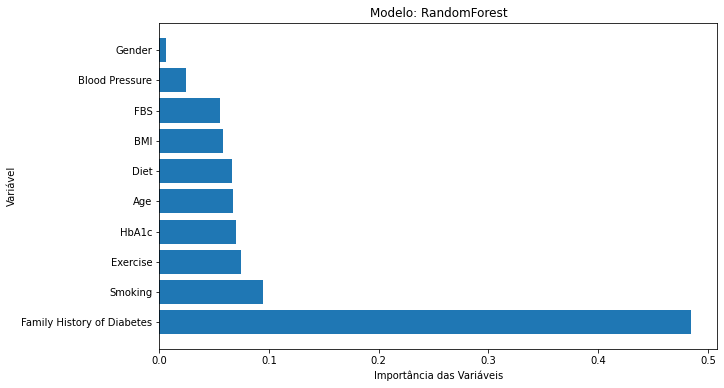

In [26]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

model = RandomForestClassifier(n_estimators=100)
model.fit(x_scaled, y)

importances = model.feature_importances_

indices = np.argsort(importances)[::-1]  
sorted_importances = importances[indices]
sorted_features = x_scaled.columns[indices]

plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances)
plt.xlabel('Importância das Variáveis')
plt.ylabel('Variável')
plt.title('Modelo: RandomForest')
plt.show()


/home/kalimara/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


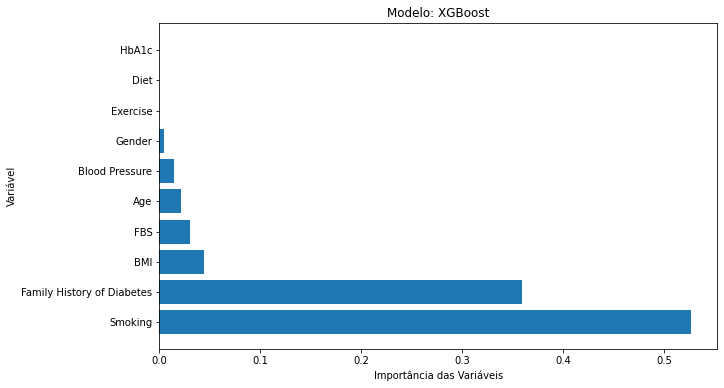

In [27]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np

model = xgb.XGBClassifier(n_estimators=100)
model.fit(x_scaled, y)

importances = model.feature_importances_

indices = np.argsort(importances)[::-1]  
sorted_importances = importances[indices]
sorted_features = x_scaled.columns[indices]

plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances)
plt.xlabel('Importância das Variáveis')
plt.ylabel('Variável')
plt.title('Modelo: XGBoost')
plt.show()


## Treinamento de Modelos

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

SEED = 42

X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, stratify=y, random_state=SEED)

dt_model = DecisionTreeClassifier(random_state=SEED)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_preds)
dt_precision = precision_score(y_test, dt_preds, average='binary')  
dt_recall = recall_score(y_test, dt_preds, average='binary')  


rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds, average='binary')  
rf_recall = recall_score(y_test, rf_preds, average='binary')  


xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=SEED)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds, average='binary')  
xgb_recall = recall_score(y_test, xgb_preds, average='binary')  

print("Acurácia: Número Total de Casos Corretos.")
print("Recall: De todos os casos com diabetes, quantos o modelo acertou?")
print("Precisão: De todos os casos que o modelos disse ser diabetes, quantos realmente eram?")

print(f"\nDecision Tree - Acurácia: {dt_accuracy:.4f}, Precisão: {dt_precision:.4f}, Recall: {dt_recall:.4f}")
print(f"\nRandom Forest - Acurácia: {rf_accuracy:.4f}, Precisão: {rf_precision:.4f}, Recall: {rf_recall:.4f}")
print(f"\nXGBoost - Acurácia: {xgb_accuracy:.4f}, Precisão: {xgb_precision:.4f}, Recall: {xgb_recall:.4f}")


Acurácia: Número Total de Casos Corretos.
Recall: De todos os casos com diabetes, quantos o modelo acertou?
Precisão: De todos os casos que o modelos disse ser diabetes, quantos realmente eram?

Decision Tree - Acurácia: 0.9231, Precisão: 1.0000, Recall: 0.6667

Random Forest - Acurácia: 0.9231, Precisão: 1.0000, Recall: 0.6667

XGBoost - Acurácia: 0.9231, Precisão: 1.0000, Recall: 0.6667
